# Изучение данных dataset_rework

**Дипломная работа.** Исследование временных рядов торговых данных: структура, пропуски, интервалы и «холодный старт» индикатора rd_value.

## Цели анализа

1. **Визуализация по монетам** — цена (close_price), rd_value и сигналы (signal_barrier) на временной шкале
2. **Пропуски** — соединять точки только при последовательных данных (интервал ≈ 1 мин)
3. **Подсветка интервалов > 1 мин** — участки, где данные не идут каждую минуту
4. **Холодный старт rd_value** — периоды, где rd_value = 0 перед появлением реальных значений

## 1. Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

In [2]:
from pathlib import Path
import sys

# Подключаем общий загрузчик из fork/dataset_rework_loader.py
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'fork').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / 'fork') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'fork'))

from dataset_rework_loader import find_dataset_rework_dir, load_dataset_rework

DATA_DIR = find_dataset_rework_dir(str(PROJECT_ROOT))
df_full = load_dataset_rework(data_dir=DATA_DIR, verbose=True)

df_full.head(20)

Найдено CSV: 833 | успешно прочитано: 833 | пропущено: 0
Загружено: 395,585 строк, 223 символов


,timestamp,symbol,rd_value,open,high,low,close_price,volume,signal_barrier,source_file,source_day,datetime
0,1770220800000,4,0.994712,0.011344,0.012135,0.011053,0.012071,41228444.0,-1,4.csv,2026-02-05,2026-02-04 16:00:00+00:00
1,1770228000000,4,0.248678,0.011384,0.011639,0.011131,0.011593,9740762.0,-1,4.csv,2026-02-05,2026-02-04 18:00:00+00:00
2,1770231600000,4,1.533739,0.011593,0.012135,0.011543,0.012071,10784302.0,1,4.csv,2026-02-05,2026-02-04 19:00:00+00:00
3,1770232500000,4,0.681662,0.011695,0.011797,0.011611,0.011661,2592977.0,-1,4.csv,2026-02-05,2026-02-04 19:15:00+00:00
4,1770233400000,4,1.005864,0.011661,0.012011,0.011660,0.011981,1812744.0,1,4.csv,2026-02-05,2026-02-04 19:30:00+00:00
5,1770233700000,4,0.532516,0.011766,0.011814,0.011754,0.011768,310401.0,-1,4.csv,2026-02-05,2026-02-04 19:35:00+00:00
6,1770234000000,4,0.740897,0.011768,0.012011,0.011761,0.011981,1217979.0,1,4.csv,2026-02-05,2026-02-04 19:40:00+00:00
7,1770234060000,4,0.466491,0.011814,0.011897,0.011814,0.011897,328690.0,-1,4.csv,2026-02-05,2026-02-04 19:41:00+00:00
8,1770234120000,4,0.601502,0.011897,0.012011,0.011897,0.011964,469995.0,1,4.csv,2026-02-05,2026-02-04 19:42:00+00:00
9,1770234180000,4,0.632386,0.011964,0.011996,0.011964,0.011992,77159.0,1,4.csv,2026-02-05,2026-02-04 19:43:00+00:00


## 2. Добавление признаков: time_diff, gap_flag, rd_cold_start

- **time_diff** — интервал до предыдущей точки (минуты)
- **gap_flag** — 1 если интервал > 1 мин, 2 если > 60 мин (пропуск сессии)
- **rd_cold_start** — 1 пока rd_value = 0 в начале серии

In [3]:
def add_time_features(df):
    df = df.sort_values(['symbol', 'datetime']).reset_index(drop=True)
    df['time_diff_min'] = df.groupby('symbol')['datetime'].diff().dt.total_seconds() / 60
    df['gap_flag'] = 0
    df.loc[df['time_diff_min'] > 1, 'gap_flag'] = 1
    df.loc[df['time_diff_min'] > 60, 'gap_flag'] = 2
    # rd_cold_start: 1 в начале серии по символу, пока rd_value=0 (холодный старт)
    cold_start = np.zeros(len(df), dtype=int)
    for sym in df['symbol'].unique():
        idx = df.index[df['symbol'] == sym].tolist()
        vals = df.loc[idx, 'rd_value'].values
        for i in range(len(vals)):
            if vals[i] == 0 and (i == 0 or cold_start[idx[i-1]] == 1):
                cold_start[idx[i]] = 1
            else:
                break
    df['rd_cold_start'] = cold_start
    return df

df_full = add_time_features(df_full)
df_full.head(10)

,timestamp,symbol,rd_value,open,high,low,close_price,volume,signal_barrier,source_file,source_day,datetime,time_diff_min,gap_flag,rd_cold_start
0,1770220800000,4,0.994712,0.011344,0.012135,0.011053,0.012071,41228444.0,-1,4.csv,2026-02-05,2026-02-04 16:00:00+00:00,NaN,0,0
1,1770228000000,4,0.248678,0.011384,0.011639,0.011131,0.011593,9740762.0,-1,4.csv,2026-02-05,2026-02-04 18:00:00+00:00,120.0,2,0
2,1770231600000,4,1.533739,0.011593,0.012135,0.011543,0.012071,10784302.0,1,4.csv,2026-02-05,2026-02-04 19:00:00+00:00,60.0,1,0
3,1770232500000,4,0.681662,0.011695,0.011797,0.011611,0.011661,2592977.0,-1,4.csv,2026-02-05,2026-02-04 19:15:00+00:00,15.0,1,0
4,1770233400000,4,1.005864,0.011661,0.012011,0.011660,0.011981,1812744.0,1,4.csv,2026-02-05,2026-02-04 19:30:00+00:00,15.0,1,0
5,1770233700000,4,0.532516,0.011766,0.011814,0.011754,0.011768,310401.0,-1,4.csv,2026-02-05,2026-02-04 19:35:00+00:00,5.0,1,0
6,1770234000000,4,0.740897,0.011768,0.012011,0.011761,0.011981,1217979.0,1,4.csv,2026-02-05,2026-02-04 19:40:00+00:00,5.0,1,0
7,1770234060000,4,0.466491,0.011814,0.011897,0.011814,0.011897,328690.0,-1,4.csv,2026-02-05,2026-02-04 19:41:00+00:00,1.0,0,0
8,1770234120000,4,0.601502,0.011897,0.012011,0.011897,0.011964,469995.0,1,4.csv,2026-02-05,2026-02-04 19:42:00+00:00,1.0,0,0
9,1770234180000,4,0.632386,0.011964,0.011996,0.011964,0.011992,77159.0,1,4.csv,2026-02-05,2026-02-04 19:43:00+00:00,1.0,0,0


## 3. Функция визуализации: сегментированный график по одной монете

- Линии соединяются **только** при интервале ≤ 1.5 мин (последовательные данные)
- Серая подсветка — интервалы > 1 мин (не минутные данные)
- Жёлтая подсветка — «холодный старт» rd_value = 0
- Маркеры BUY (зелёные) и SELL (красные)

In [4]:
def plot_symbol_segmented(df_symbol, symbol_name, max_points=2000, gap_threshold_min=1.5):
    """
    Строит график для одной монеты с разрывом линий при пропусках.
    gap_threshold_min: при интервале > threshold линия не соединяется.
    """
    df = df_symbol.sort_values('datetime').reset_index(drop=True).copy()

    # При даунсемплинге увеличиваем порог сегментации, иначе линия может пропасть
    # (например, шаг 4 минуты при пороге 1.5 минуты).
    step = 1
    if len(df) > max_points:
        step = max(1, int(np.ceil(len(df) / max_points)))
        df = df.iloc[::step].reset_index(drop=True)
        df['time_diff_min'] = df['datetime'].diff().dt.total_seconds() / 60

    effective_gap_threshold = gap_threshold_min * step

    x = df['datetime'].values
    price = df['close_price'].values
    rd = df['rd_value'].values
    td = df['time_diff_min'].fillna(0).values
    cold = df['rd_cold_start'].values if 'rd_cold_start' in df.columns else np.zeros(len(df))
    barrier = df['signal_barrier'].values if 'signal_barrier' in df.columns else np.zeros(len(df))

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

    # Подсветка: интервалы > порога (серая) и холодный старт rd_value=0 (жёлтая)
    cold_idx = np.where(cold == 1)[0]
    cold_start_end = (cold_idx[0], cold_idx[-1]) if len(cold_idx) > 0 else (None, None)
    for ax in axes:
        for i in range(1, len(x)):
            if td[i] > effective_gap_threshold:
                ax.axvspan(x[i-1], x[i], alpha=0.25, color='gray', zorder=0, label='_nolegend_')
        if cold_start_end[0] is not None:
            pad = (x[-1] - x[0]) * 0.002 if len(x) > 1 else pd.Timedelta(minutes=1)
            ax.axvspan(
                x[cold_start_end[0]] - pad,
                x[cold_start_end[1]] + pad,
                alpha=0.25,
                color='gold',
                zorder=0,
                label='rd_value=0 (холодный старт)' if ax == axes[0] else '_nolegend_'
            )

    # Сегменты цены (соединяем только при td <= effective_gap_threshold)
    ax1 = axes[0]
    seg_start = 0
    for i in range(1, len(x) + 1):
        if i == len(x) or td[i] > effective_gap_threshold:
            if i - seg_start > 1:
                ax1.plot(x[seg_start:i], price[seg_start:i], color='#2563eb', linewidth=1.5, zorder=2)
            seg_start = i
    ax1.set_ylabel('close_price', fontsize=12)
    ax1.set_title(
        f'{symbol_name}: цена, rd_value и сигналы '
        f'(серая = пропуск >{effective_gap_threshold:.1f} мин, жёлтая = rd_value=0)'
    )
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='y')

    # Маркеры BUY / SELL
    buy_idx = np.where(barrier == 1)[0]
    sell_idx = np.where(barrier == -1)[0]
    if len(buy_idx) > 0:
        ax1.scatter(x[buy_idx], price[buy_idx], color='green', s=30, marker='^', label='BUY', zorder=3)
    if len(sell_idx) > 0:
        ax1.scatter(x[sell_idx], price[sell_idx], color='red', s=30, marker='v', label='SELL', zorder=3)
    ax1.legend(loc='upper right')

    # Сегменты rd_value
    ax2 = axes[1]
    seg_start = 0
    for i in range(1, len(x) + 1):
        if i == len(x) or td[i] > effective_gap_threshold:
            if i - seg_start > 1:
                ax2.plot(x[seg_start:i], rd[seg_start:i], color='#7c3aed', linewidth=1.2, zorder=2)
            seg_start = i

    # Ограничиваем влияние экстремумов, чтобы динамика rd_value была видна лучше
    rd_valid = pd.Series(rd).dropna()
    if len(rd_valid) >= 20:
        q01, q99 = rd_valid.quantile([0.01, 0.99])
        if np.isfinite(q01) and np.isfinite(q99) and q99 > q01:
            pad = max((q99 - q01) * 0.1, 1e-6)
            ax2.set_ylim(q01 - pad, q99 + pad)

    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.set_ylabel('rd_value', fontsize=12)
    ax2.set_xlabel('время')
    fig.autofmt_xdate()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Визуализация нескольких монет

In [5]:
# Выбираем монеты с достаточным объёмом данных (топ по количеству записей)
top_symbols = df_full.groupby('symbol').size().sort_values(ascending=False).head(12).index.tolist()
print('Монеты для визуализации:', top_symbols[:8])

Монеты для визуализации: ['ARC', 'FHE', 'STABLE', 'ROAM', 'FIGHT', 'WHITEWHALE', 'ACU', 'CYS']


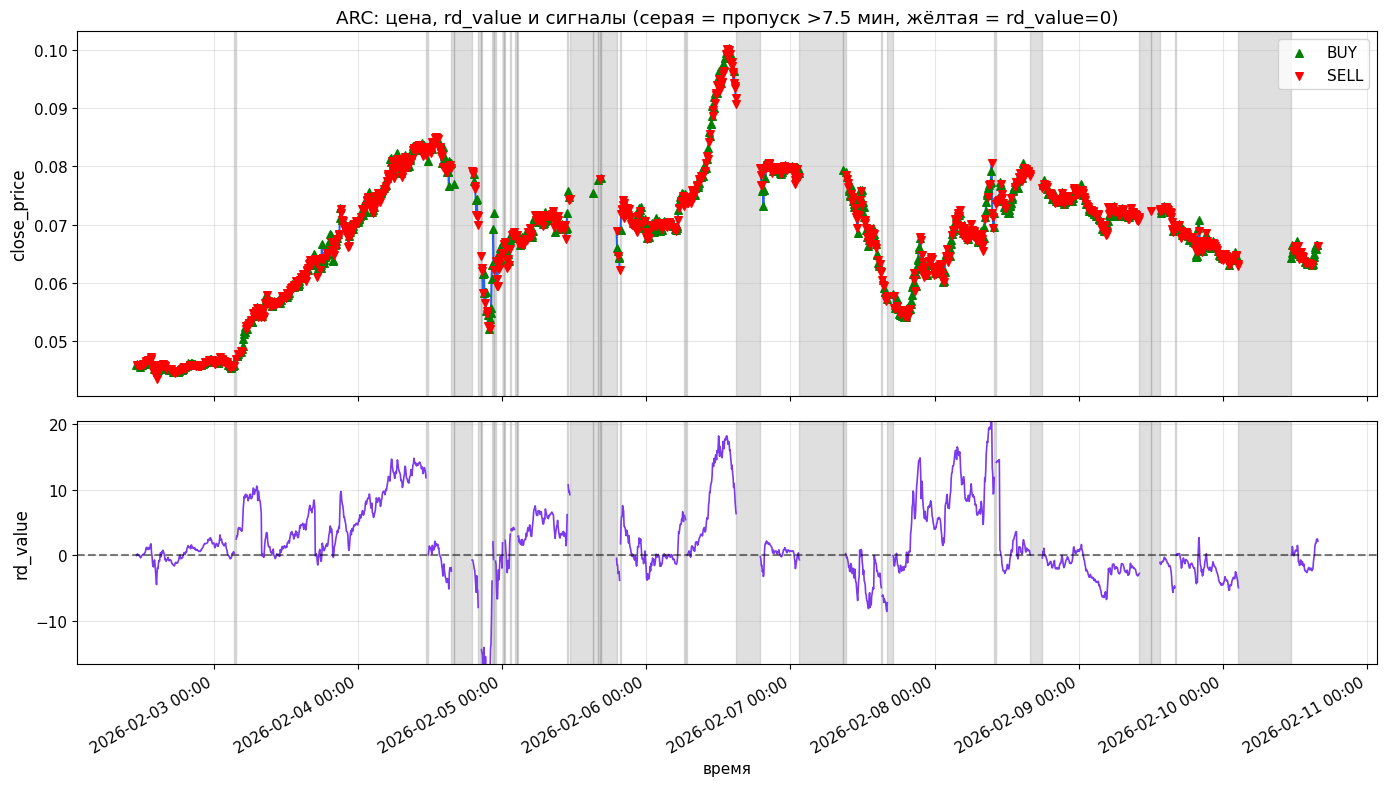

In [6]:
# Пример 1: ARC
sym = top_symbols[0] if top_symbols else df_full['symbol'].iloc[0]
plot_symbol_segmented(df_full[df_full['symbol'] == sym], sym)

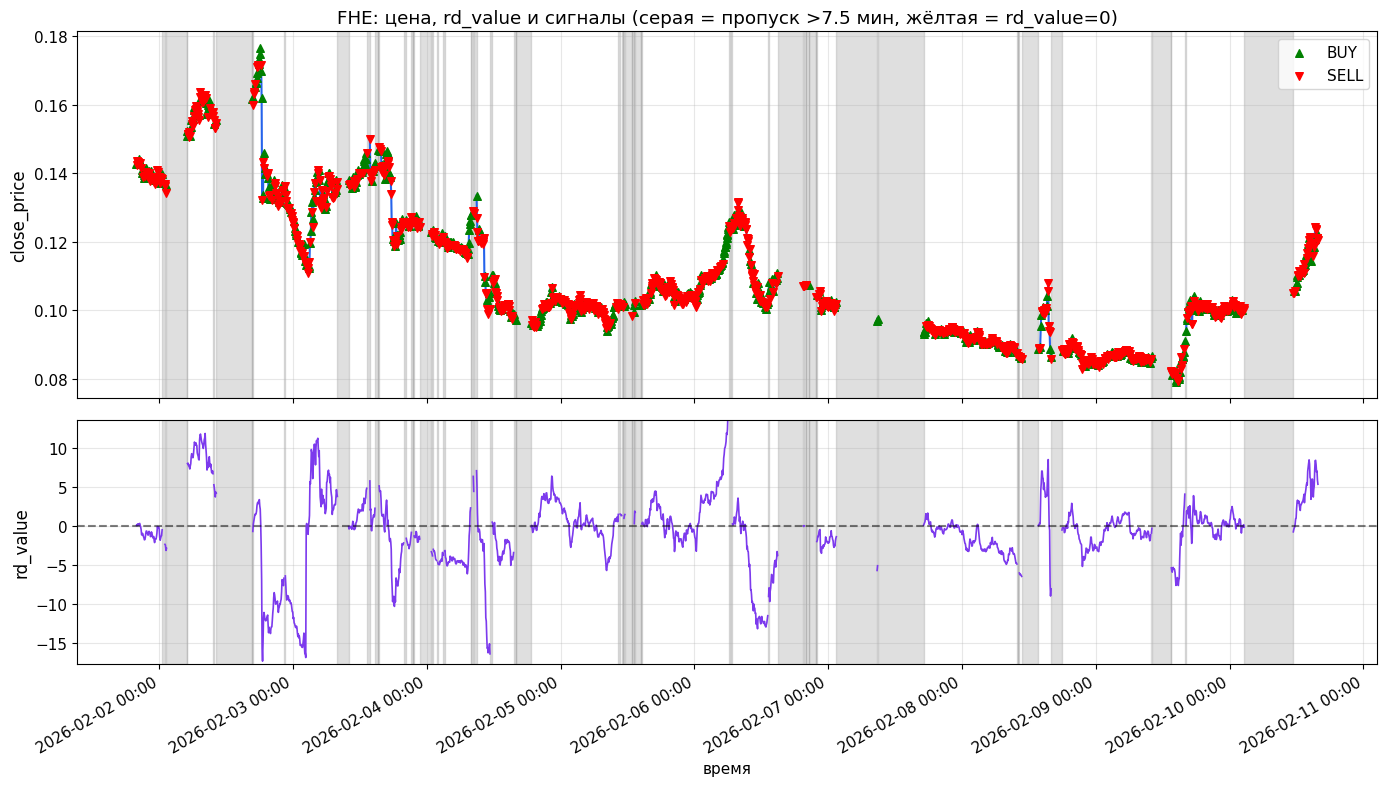

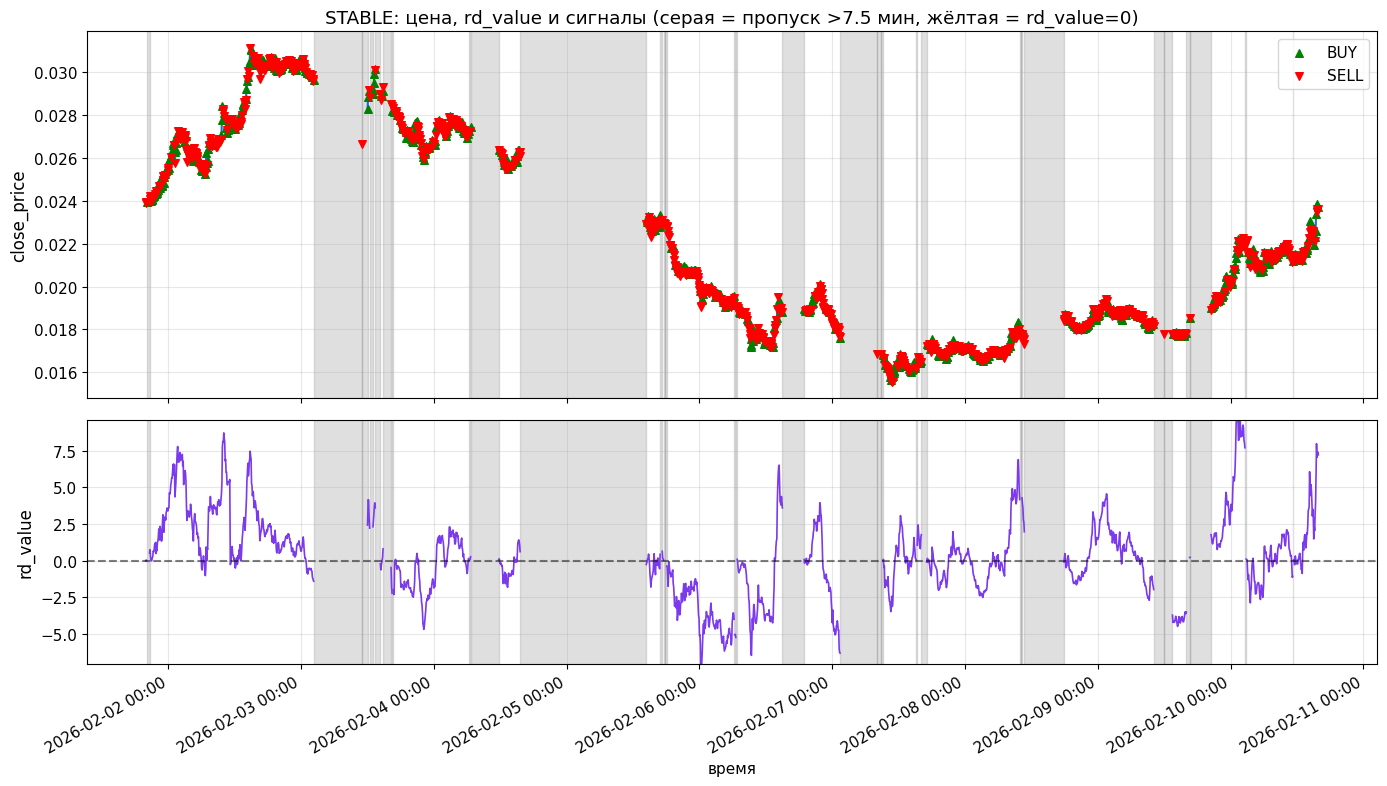

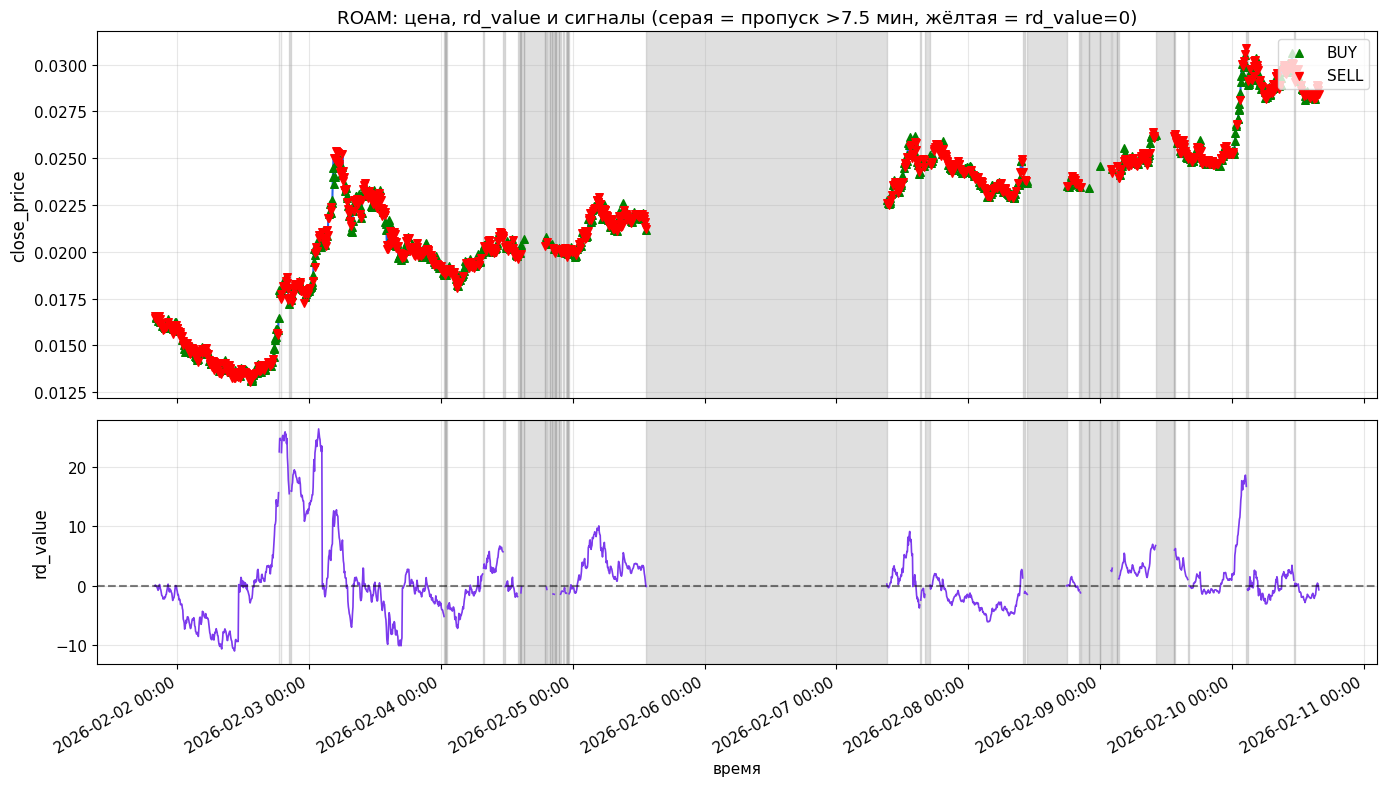

In [7]:
# Пример 2–4: ещё несколько монет
for sym in top_symbols[1:4]:
    plot_symbol_segmented(df_full[df_full['symbol'] == sym], sym)

## 5. Сводная статистика по пропускам и «холодному старту»

In [8]:
# Доля интервалов > 1 мин
td = df_full['time_diff_min'].dropna()
n_total = len(td)
n_gt1 = (td > 1).sum()
n_gt5 = (td > 5).sum()
n_gt60 = (td > 60).sum()
print('Интервалы между точками:')
print(f'  Всего: {n_total:,}')
print(f'  > 1 мин: {n_gt1:,} ({100*n_gt1/n_total:.2f}%)')
print(f'  > 5 мин: {n_gt5:,} ({100*n_gt5/n_total:.2f}%)')
print(f'  > 60 мин: {n_gt60:,} ({100*n_gt60/n_total:.2f}%)')

# Холодный старт rd_value
cold_count = (df_full['rd_cold_start'] == 1).sum()
print(f'\nТочек в «холодном старте» (rd_value=0): {cold_count:,} ({100*cold_count/len(df_full):.2f}%)')

Интервалы между точками:
  Всего: 395,362
  > 1 мин: 4,879 (1.23%)
  > 5 мин: 2,353 (0.60%)
  > 60 мин: 632 (0.16%)

Точек в «холодном старте» (rd_value=0): 0 (0.00%)


In [9]:
# Распределение длительности «холодного старта» по символам (в количестве точек)
cold_len = df_full.groupby('symbol')['rd_cold_start'].apply(lambda x: (x == 1).sum())
cold_len = cold_len[cold_len > 0].sort_values(ascending=False)
print('Символы с наибольшим «холодным стартом» (точек с rd_value=0):')
print(cold_len.head(15).to_string())

Символы с наибольшим «холодным стартом» (точек с rd_value=0):
Series([], )


## 5.1 Фильтрация для модели: убираем интервалы > 1.5 мин

Для обучения оставляем почти все данные, но исключаем точки после больших разрывов времени (`time_diff_min > 1.5`).
Это мягкая очистка: удаляет только явно нерегулярные интервалы.

In [10]:
# Мягкая фильтрация нерегулярных интервалов для ML
FILTER_THRESHOLD_MIN = 1.5

mask_irregular = df_full['time_diff_min'] > FILTER_THRESHOLD_MIN
df_model = df_full.loc[~mask_irregular].copy()

removed_rows = int(mask_irregular.sum())
removed_pct = removed_rows / len(df_full) * 100

print(f'Порог фильтрации: time_diff_min > {FILTER_THRESHOLD_MIN} мин')
print(f'Удалено строк: {removed_rows:,} ({removed_pct:.2f}%)')
print(f'Осталось для модели: {len(df_model):,} строк ({100 - removed_pct:.2f}%)')
print(f'Символов после фильтрации: {df_model["symbol"].nunique()}')

# Как фильтрация влияет на баланс классов
before_dist = (df_full['signal_barrier'].value_counts(normalize=True) * 100).sort_index()
after_dist = (df_model['signal_barrier'].value_counts(normalize=True) * 100).sort_index()

cmp = pd.DataFrame({
    'before_%': before_dist.round(3),
    'after_%': after_dist.round(3)
}).fillna(0)
print('\nРаспределение signal_barrier до/после фильтрации (%):')
print(cmp.to_string())

# Символы, где фильтрация сработала сильнее всего
removed_by_symbol = (df_full.assign(is_removed=mask_irregular)
    .groupby('symbol')['is_removed']
    .mean()
    .mul(100)
    .sort_values(ascending=False))

print('\nТоп-15 символов по доле удалённых строк (%):')
print(removed_by_symbol.head(15).round(2).to_string())

Порог фильтрации: time_diff_min > 1.5 мин
Удалено строк: 4,879 (1.23%)
Осталось для модели: 390,706 строк (98.77%)
Символов после фильтрации: 223

Распределение signal_barrier до/после фильтрации (%):
                before_%  after_%
signal_barrier                   
-1                 50.28   50.265
 1                 49.72   49.735

Топ-15 символов по доле удалённых строк (%):
symbol
SOON       57.89
SPX        18.33
BSV        11.24
DBR        10.24
BRETT       7.41
PUMPFUN     7.40
RAYDIUM     7.19
AVL         6.85
HOLO        6.32
XCH         5.38
USUAL       4.78
SPK         4.69
SENT        4.54
EUL         4.53
ARK         4.12


## 12. Анализ is_first: первые записи сессий vs общее распределение

(По мотивам ml_data_loader_отНатали: там в первых записях сессий BUY/SELL встречались чаще, чем в среднем.)

Проверяем на наших очищенных данных: **есть ли разница в распределении signal_barrier** между первыми точками сессий (is_first=1) и остальными. Если да — имеет смысл добавить is_first как фичу.

In [ ]:
# is_first = 1 для первой точки каждой сессии
work['is_first'] = (work.groupby('session_key').cumcount() == 0).astype(int)

# Очищенные данные: только сессии >= 60 точек (как для обучения)
valid_sessions = sessions[sessions['ok_for_train']]['session_key'].values
work_clean = work[work['session_key'].isin(valid_sessions)].copy()

# Общее распределение signal_barrier (очищенные данные)
total_n = len(work_clean)
buy_all = (work_clean['signal_barrier'] == 1).sum()
sell_all = (work_clean['signal_barrier'] == -1).sum()
buy_pct_all = 100 * buy_all / total_n
sell_pct_all = 100 * sell_all / total_n

# Распределение в ПЕРВЫХ записях сессий (is_first == 1)
first_records = work_clean[work_clean['is_first'] == 1]
first_n = len(first_records)
buy_first = (first_records['signal_barrier'] == 1).sum()
sell_first = (first_records['signal_barrier'] == -1).sum()
buy_pct_first = 100 * buy_first / first_n if first_n > 0 else 0
sell_pct_first = 100 * sell_first / first_n if first_n > 0 else 0

print('=== is_first: первые записи сессий vs общее распределение ===')
print('(Очищенные данные: time_diff <= 1.5 мин, сессии >= 60 точек)\n')
print(f'Всего записей: {total_n:,}')
print(f'Первых записей (is_first=1): {first_n:,}\n')
print('Распределение signal_barrier:')
print('-' * 60)
print(f'{"Сигнал":12} | {"ВСЕ записи":>16} | {"ПЕРВЫЕ записи":>16} | {"Разница (п.п.)":>12}')
print('-' * 60)
print(f'{"BUY (1)":12} | {buy_pct_all:>14.2f}% | {buy_pct_first:>14.2f}% | {buy_pct_first - buy_pct_all:>+10.2f}')
print(f'{"SELL (-1)":12} | {sell_pct_all:>14.2f}% | {sell_pct_first:>14.2f}% | {sell_pct_first - sell_pct_all:>+10.2f}')
print('-' * 60)

# Вывод: повторяется ли паттерн из ml_data_loader_отНатали?
# У Натали: первые записи — SELL чаще (10.58% vs 7.18%), BUY чаще (4.56% vs 1.99%)
# У нас: если BUY/SELL в первых записях заметно отличаются от среднего — есть смысл в is_first
diff_buy = abs(buy_pct_first - buy_pct_all)
diff_sell = abs(sell_pct_first - sell_pct_all)
threshold = 1.0  # порог в проц. пунктах

if diff_buy >= threshold or diff_sell >= threshold:
    print('\n✅ Есть заметная разница (>= 1 п.п.): имеет смысл добавить is_first как фичу.')
else:
    print('\n⚠️ Разница небольшая (< 1 п.п.): is_first может быть малополезен.')

## 6. Гистограмма интервалов (time_diff)

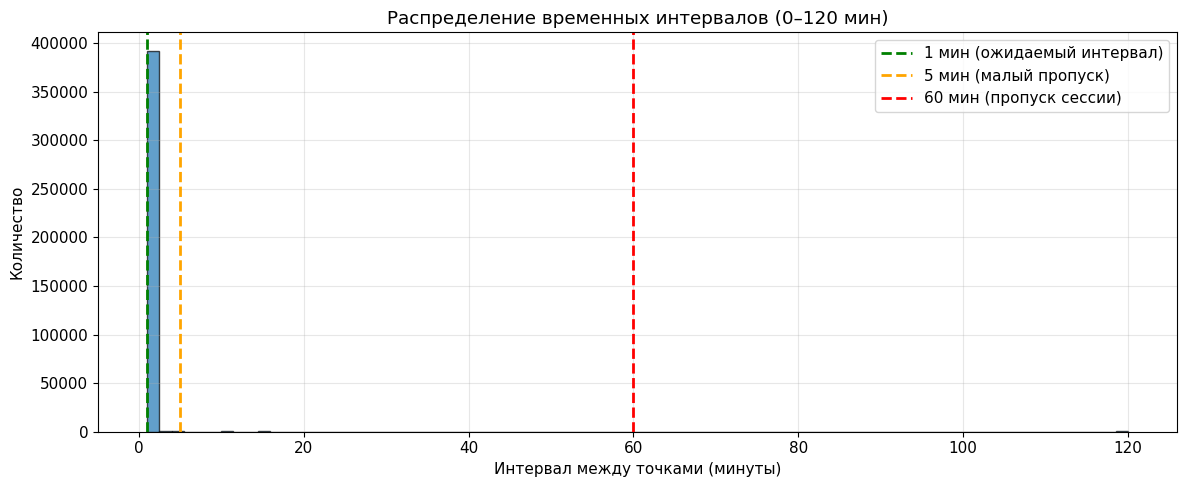

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
td_clip = td.clip(upper=120)  # обрезаем для наглядности
ax.hist(td_clip, bins=80, edgecolor='black', alpha=0.7)
ax.axvline(1, color='green', linestyle='--', linewidth=2, label='1 мин (ожидаемый интервал)')
ax.axvline(5, color='orange', linestyle='--', linewidth=2, label='5 мин (малый пропуск)')
ax.axvline(60, color='red', linestyle='--', linewidth=2, label='60 мин (пропуск сессии)')
ax.set_xlabel('Интервал между точками (минуты)')
ax.set_ylabel('Количество')
ax.set_title('Распределение временных интервалов (0–120 мин)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Распределение signal_barrier

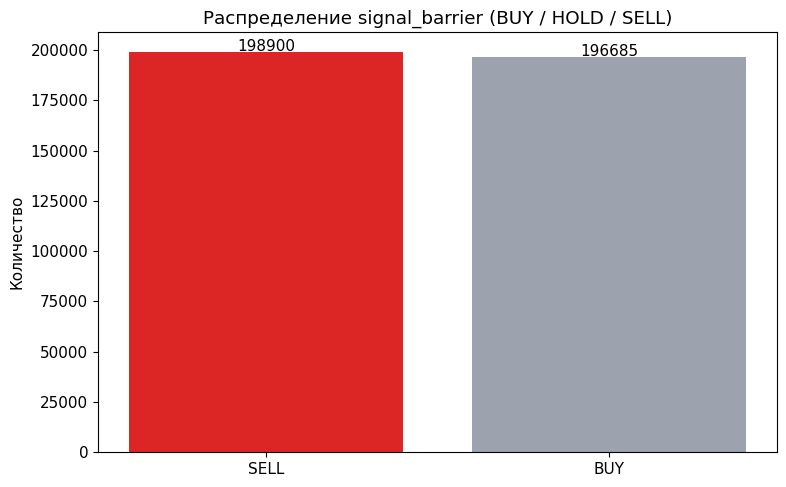

In [12]:
counts = df_full['signal_barrier'].value_counts().sort_index()
labels = {-1: 'SELL', 0: 'HOLD', 1: 'BUY'}
x_labels = [labels.get(k, str(k)) for k in counts.index]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x_labels, counts.values, color=['#dc2626', '#9ca3af', '#16a34a'])
ax.set_ylabel('Количество')
ax.set_title('Распределение signal_barrier (BUY / HOLD / SELL)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 500, str(int(b.get_height())), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Монета с выраженным «холодным стартом»

Выбираем символ, где rd_value долго равен 0 в начале, и строим увеличенный фрагмент.

In [13]:
if len(cold_len) > 0:
    sym_cold = cold_len.index[0]
    df_c = df_full[df_full['symbol'] == sym_cold].head(500)
    plot_symbol_segmented(df_c, f'{sym_cold} (первые 500 точек)')
else:
    print('Нет данных с rd_value=0 в начале.')

Нет данных с rd_value=0 в начале.


---
**Выводы** (для диплома и обсуждения с коллегами):
- Линии на графиках разрываются при пропусках > 1.5 мин, чтобы не создавать ложных трендов.
- Серая подсветка показывает участки с нестандартными интервалами (например, данные не каждую минуту).
- Жёлтая подсветка — «холодный старт» rd_value, когда индикатор ещё равен 0.
- BUY/SELL маркеры помогают соотносить сигналы с ценой и rd_value.

## 9. Расширенный аудит качества данных и покрытия

Ниже — детальная проверка качества `dataset_rework`:
- покрытие по дням и источникам
- пропуски и дубликаты
- стабильность минутного шага по символам
- распределения и аномалии по ключевым колонкам

Колонки в датасете: ['close_price', 'datetime', 'gap_flag', 'high', 'low', 'open', 'rd_cold_start', 'rd_value', 'signal_barrier', 'source_day', 'source_file', 'symbol', 'time_diff_min', 'timestamp', 'volume']
Размер датасета: (395585, 15)

Пропуски по ключевым колонкам (%):
timestamp         0.0
symbol            0.0
rd_value          0.0
close_price       0.0
volume            0.0
signal_barrier    0.0
source_day        0.0
source_file       0.0
datetime          0.0



Полные дубликаты строк: 0
Дубликаты по ключу (symbol, timestamp): 0

Покрытие по source_day (первые 15):
               rows  symbols  files                    ts_min                    ts_max
source_day                                                                             
2026-02-01-2   4537       15     15 2026-02-01 10:35:00+00:00 2026-02-01 17:11:00+00:00
2026-02-02    30838       46     46 2026-02-01 19:52:00+00:00 2026-02-02 11:06:00+00:00
2026-02-03    33512       48     48 2026-02-02 11:08:00+00:00 2026-02-03 02:20:00+00:00
2026-02-03-2   8106       31     31 2026-02-03 02:21:00+00:00 2026-02-03 07:58:00+00:00
2026-02-03-3   3048       29     29 2026-02-03 07:59:00+00:00 2026-02-03 09:54:00+00:00
2026-02-03-4  11687       34     34 2026-02-03 09:55:00+00:00 2026-02-03 16:55:00+00:00
2026-02-04    29891       44     44 2026-02-03 16:54:00+00:00 2026-02-04 11:20:00+00:00
2026-02-04-2   7051       34     34 2026-02-04 11:40:00+00:00 2026-02-04 15:37:00+00:00
2026-02-05    


Топ-15 символов по объему данных:
            rows                     start                       end  minutes_median  gap_gt_1m_pct  rd_zero_pct  buy_pct  sell_pct  hold_pct
symbol                                                                                                                                       
ARC         9405 2026-02-02 11:08:00+00:00 2026-02-10 15:52:00+00:00             1.0          0.691          0.0   49.335    50.665       0.0
FHE         8912 2026-02-01 19:54:00+00:00 2026-02-10 15:52:00+00:00             1.0          1.133          0.0   50.213    49.787       0.0
STABLE      8561 2026-02-01 19:54:00+00:00 2026-02-10 15:52:00+00:00             1.0          0.771          0.0   48.791    51.209       0.0
ROAM        8499 2026-02-01 19:54:00+00:00 2026-02-10 15:52:00+00:00             1.0          1.141          0.0   49.323    50.677       0.0
FIGHT       8490 2026-02-01 10:35:00+00:00 2026-02-10 11:18:00+00:00             1.0          1.390          0.0 

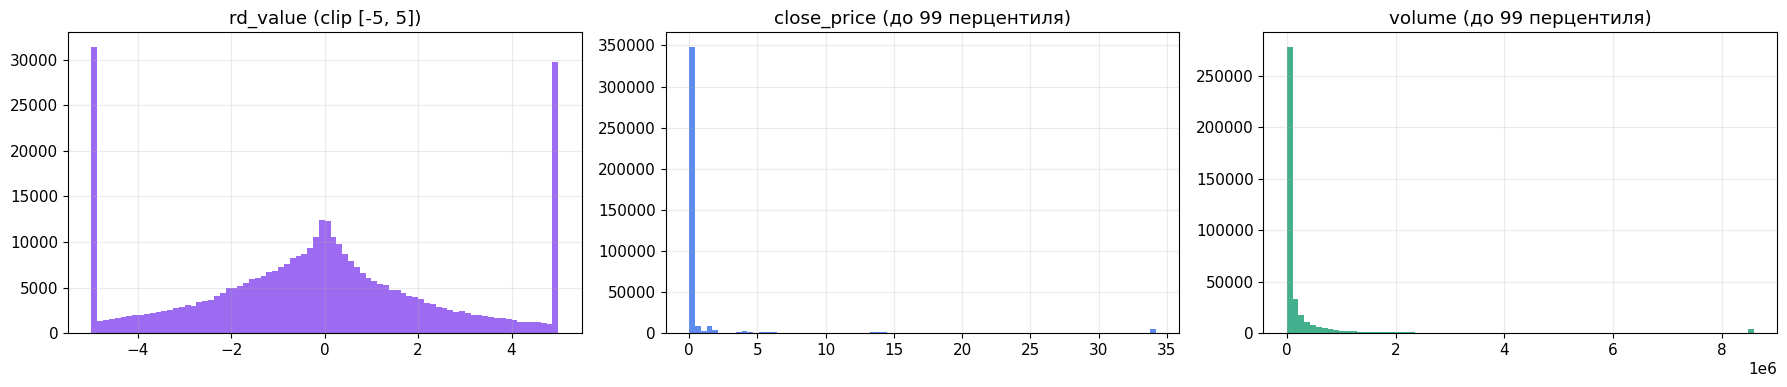


Корреляционная матрица:
               rd_value  close_price  volume  time_diff_min
rd_value         1.0000      -0.0001  0.0069         0.0000
close_price     -0.0001       1.0000 -0.0046        -0.0009
volume           0.0069      -0.0046  1.0000         0.0051
time_diff_min    0.0000      -0.0009  0.0051         1.0000


In [14]:
# 9.1 Базовый аудит структуры и качества
base_cols = ['timestamp', 'symbol', 'rd_value', 'close_price', 'volume', 'signal_barrier', 'source_day', 'source_file', 'datetime']
print('Колонки в датасете:', sorted(df_full.columns.tolist()))
print('Размер датасета:', df_full.shape)

missing_stats = (df_full[base_cols]
                 .isna()
                 .mean()
                 .mul(100)
                 .round(3)
                 .sort_values(ascending=False)
                 .rename('% missing'))
print('\nПропуски по ключевым колонкам (%):')
print(missing_stats.to_string())

exact_dups = int(df_full.duplicated().sum())
key_dups = int(df_full.duplicated(subset=['symbol', 'timestamp']).sum())
print(f'\nПолные дубликаты строк: {exact_dups:,}')
print(f'Дубликаты по ключу (symbol, timestamp): {key_dups:,}')

# 9.2 Покрытие по дням (source_day)
day_coverage = (df_full.groupby('source_day')
                .agg(
                    rows=('timestamp', 'size'),
                    symbols=('symbol', 'nunique'),
                    files=('source_file', 'nunique'),
                    ts_min=('datetime', 'min'),
                    ts_max=('datetime', 'max')
                )
                .sort_values('ts_min'))
print('\nПокрытие по source_day (первые 15):')
print(day_coverage.head(15).to_string())

# 9.3 Метрики непрерывности по символам
sym_stats = (df_full.sort_values(['symbol', 'datetime'])
             .groupby('symbol')
             .apply(lambda g: pd.Series({
                 'rows': len(g),
                 'start': g['datetime'].iloc[0],
                 'end': g['datetime'].iloc[-1],
                 'minutes_median': g['datetime'].diff().dt.total_seconds().div(60).median(),
                 'gap_gt_1m_pct': g['datetime'].diff().dt.total_seconds().div(60).gt(1).mean() * 100,
                 'rd_zero_pct': g['rd_value'].eq(0).mean() * 100 if 'rd_value' in g else np.nan,
                 'buy_pct': g['signal_barrier'].eq(1).mean() * 100 if 'signal_barrier' in g else np.nan,
                 'sell_pct': g['signal_barrier'].eq(-1).mean() * 100 if 'signal_barrier' in g else np.nan,
                 'hold_pct': g['signal_barrier'].eq(0).mean() * 100 if 'signal_barrier' in g else np.nan,
             })))

sym_stats = sym_stats.sort_values('rows', ascending=False)
print('\nТоп-15 символов по объему данных:')
print(sym_stats.head(15).round(3).to_string())

print('\nСимволы с наибольшей долей разрывов (>1 мин), минимум 500 точек:')
high_gap = sym_stats[sym_stats['rows'] >= 500].sort_values('gap_gt_1m_pct', ascending=False).head(15)
print(high_gap[['rows', 'gap_gt_1m_pct', 'minutes_median']].round(3).to_string())

# 9.4 Сводные распределения по значениям
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df_full['rd_value'].clip(-5, 5).hist(bins=80, ax=axes[0], color='#7c3aed', alpha=0.75)
axes[0].set_title('rd_value (clip [-5, 5])')
axes[0].grid(True, alpha=0.25)

df_full['close_price'].clip(upper=df_full['close_price'].quantile(0.99)).hist(bins=80, ax=axes[1], color='#2563eb', alpha=0.75)
axes[1].set_title('close_price (до 99 перцентиля)')
axes[1].grid(True, alpha=0.25)

df_full['volume'].clip(upper=df_full['volume'].quantile(0.99)).hist(bins=80, ax=axes[2], color='#059669', alpha=0.75)
axes[2].set_title('volume (до 99 перцентиля)')
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# 9.5 Корреляции ключевых numeric колонок
num_cols = [c for c in ['rd_value', 'close_price', 'volume', 'time_diff_min'] if c in df_full.columns]
if len(num_cols) >= 2:
    corr = df_full[num_cols].corr(numeric_only=True)
    print('\nКорреляционная матрица:')
    print(corr.round(4).to_string())
else:
    print('\nНедостаточно numeric колонок для корреляций.')

## 10. Model-oriented анализ (вместо общей корреляционной матрицы)

Этот блок показывает, какие признаки реально полезны для разделения `BUY` и `SELL` на текущих данных.
Используется мягко очищенный набор (`df_model`) с фильтром `time_diff_min <= 1.5`.

Источник: df_model (time_diff_min <= 1.5)
Строк: 390,706 | Символов: 223
Баланс классов signal_barrier (%):
signal_barrier
-1    50.265
 1    49.735



Информативность признаков для BUY vs SELL:
   feature  global_corr_with_buy  auc_direction_free  median_symbol_corr  mean_abs_symbol_corr  n_rows
  rd_mom_1                0.2724              0.9954              0.3823                0.4048  390483
     ret_1                0.3223              0.8094              0.3769                0.3713  390483
  rd_mom_5                0.1742              0.7032              0.2250                0.2334  389591
log_volume               -0.0098              0.5040             -0.0047                0.0491  390706
    abs_rd                0.0058              0.5036              0.0056                0.0358  390706
  rd_value                0.0012              0.5025              0.0052                0.0412  390706


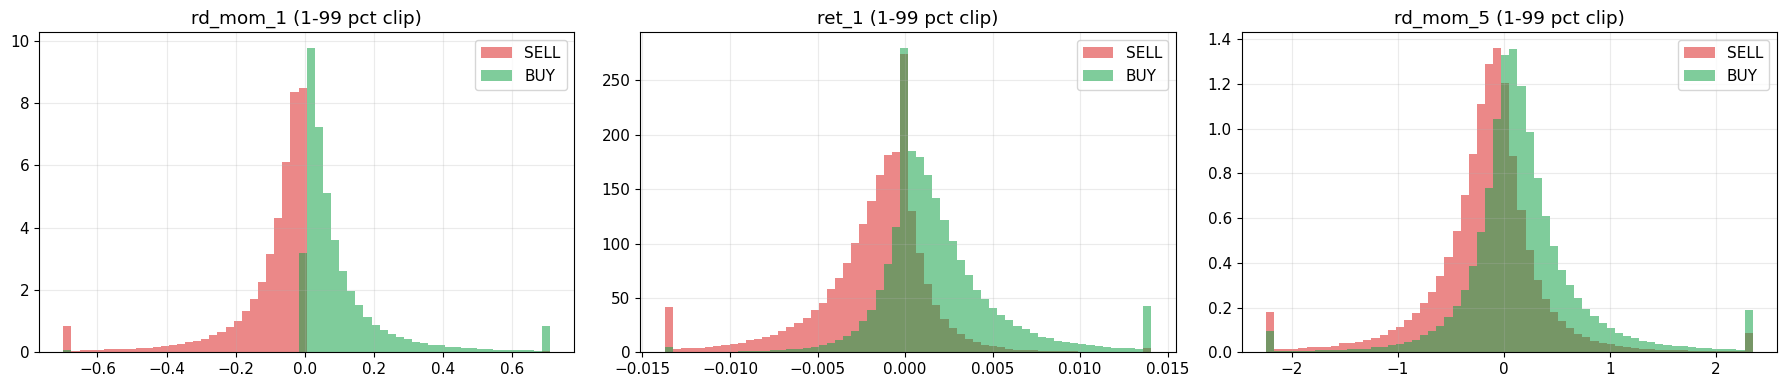


Короткий вывод:
Лучший простой признак сейчас: rd_mom_1 (AUC≈0.995, corr≈0.272).
Общая корреляционная матрица уровней (rd/price/volume) малоинформативна для задачи классификации.


In [15]:
from sklearn.metrics import roc_auc_score

# Берем мягко очищенные данные (или считаем локально при необходимости)
if 'df_model' in globals():
    work_df = df_model.copy()
    source_name = 'df_model (time_diff_min <= 1.5)'
else:
    work_df = df_full[df_full['time_diff_min'].fillna(0) <= 1.5].copy()
    source_name = 'df_full с локальным фильтром time_diff_min <= 1.5'

work_df = work_df.sort_values(['symbol', 'datetime']).reset_index(drop=True)
work_df = work_df[work_df['signal_barrier'].isin([-1, 1])].copy()
work_df['y_buy'] = (work_df['signal_barrier'] == 1).astype(int)

# Простые производные признаки (более практичны, чем общая матрица raw-уровней)
work_df['ret_1'] = work_df.groupby('symbol')['close_price'].pct_change()
work_df['rd_mom_1'] = work_df.groupby('symbol')['rd_value'].diff(1)
work_df['rd_mom_5'] = work_df.groupby('symbol')['rd_value'].diff(5)
work_df['abs_rd'] = work_df['rd_value'].abs()
work_df['log_volume'] = np.log1p(work_df['volume'].clip(lower=0))

print(f'Источник: {source_name}')
print(f'Строк: {len(work_df):,} | Символов: {work_df["symbol"].nunique()}')
print('Баланс классов signal_barrier (%):')
print((work_df['signal_barrier'].value_counts(normalize=True) * 100).sort_index().round(3).to_string())

candidate_features = ['rd_value', 'abs_rd', 'rd_mom_1', 'rd_mom_5', 'ret_1', 'log_volume']
rows = []

for feat in candidate_features:
    tmp = work_df[[feat, 'y_buy', 'symbol']].dropna()
    if len(tmp) < 1000 or tmp[feat].nunique() < 2:
        continue

    corr = tmp[feat].corr(tmp['y_buy'])

    try:
        auc_raw = roc_auc_score(tmp['y_buy'], tmp[feat])
        auc_direction_free = max(auc_raw, 1 - auc_raw)
    except Exception:
        auc_direction_free = np.nan

    per_symbol_corr = tmp.groupby('symbol').apply(
        lambda g: g[feat].corr(g['y_buy']) if g[feat].nunique() > 1 and g['y_buy'].nunique() > 1 else np.nan
    ).dropna()

    rows.append({
        'feature': feat,
        'global_corr_with_buy': corr,
        'auc_direction_free': auc_direction_free,
        'median_symbol_corr': per_symbol_corr.median() if len(per_symbol_corr) else np.nan,
        'mean_abs_symbol_corr': per_symbol_corr.abs().mean() if len(per_symbol_corr) else np.nan,
        'n_rows': len(tmp)
    })

score_df = pd.DataFrame(rows).sort_values(['auc_direction_free', 'mean_abs_symbol_corr'], ascending=False)

print('\nИнформативность признаков для BUY vs SELL:')
print(score_df.round(4).to_string(index=False))

# Визуально сравниваем распределения 3 лучших признаков по классам
top_feats = score_df['feature'].head(3).tolist()
if top_feats:
    fig, axes = plt.subplots(1, len(top_feats), figsize=(6 * len(top_feats), 4))
    if len(top_feats) == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_feats):
        buy_vals = work_df.loc[work_df['signal_barrier'] == 1, feat].dropna()
        sell_vals = work_df.loc[work_df['signal_barrier'] == -1, feat].dropna()

        lo = work_df[feat].quantile(0.01)
        hi = work_df[feat].quantile(0.99)
        buy_vals = buy_vals.clip(lo, hi)
        sell_vals = sell_vals.clip(lo, hi)

        ax.hist(sell_vals, bins=60, alpha=0.55, color='#dc2626', label='SELL', density=True)
        ax.hist(buy_vals, bins=60, alpha=0.55, color='#16a34a', label='BUY', density=True)
        ax.set_title(f'{feat} (1-99 pct clip)')
        ax.grid(True, alpha=0.25)
        ax.legend()

    plt.tight_layout()
    plt.show()

if not score_df.empty:
    best = score_df.iloc[0]
    print('\nКороткий вывод:')
    print(
        f"Лучший простой признак сейчас: {best['feature']} "
        f"(AUC≈{best['auc_direction_free']:.3f}, corr≈{best['global_corr_with_buy']:.3f})."
    )
    print('Общая корреляционная матрица уровней (rd/price/volume) малоинформативна для задачи классификации.')

## 11. Непрерывность данных и сессии (важно для обучения)

Данные могут быть разрознены во времени: между строками возможны разрывы в несколько минут или часов.
Модель не понимает разрывы — ей нужны последовательности только внутри непрерывных сессий.
Ниже: разбиение на сессии (gap > порог = новая сессия), статистика и выводы для pipeline обучения.

In [16]:
# Порог разрыва: если time_diff > N мин — новая сессия
SESSION_GAP_THRESHOLD_MIN = 1.5
MIN_SESSION_LENGTH = 60  # сессии короче этого — отбрасывать для обучения

# Берём очищенные данные (если есть df_model, иначе df_full с фильтром)
work = (df_model.copy() if 'df_model' in globals() else
        df_full[df_full['time_diff_min'].fillna(0) <= SESSION_GAP_THRESHOLD_MIN].copy())
work = work.sort_values(['symbol', 'datetime']).reset_index(drop=True)

# Пересчитываем time_diff и session_id
work['time_diff_min'] = work.groupby('symbol')['datetime'].diff().dt.total_seconds() / 60
work['new_session'] = (work['time_diff_min'].fillna(0) > SESSION_GAP_THRESHOLD_MIN).astype(int)
work['session_id'] = work.groupby('symbol')['new_session'].cumsum()
work['session_key'] = work['symbol'].astype(str) + '_s' + work['session_id'].astype(str)

# Агрегация по сессиям
sessions = work.groupby('session_key').agg(
    symbol=('symbol', 'first'),
    rows=('timestamp', 'size'),
    start=('datetime', 'min'),
    end=('datetime', 'max'),
    max_gap_min=('time_diff_min', lambda s: s.dropna().max() if len(s.dropna()) else 0),
).reset_index()

sessions['duration_min'] = (sessions['end'] - sessions['start']).dt.total_seconds() / 60
sessions['ok_for_train'] = sessions['rows'] >= MIN_SESSION_LENGTH

total_rows = len(work)
total_sessions = len(sessions)
short_sessions = (sessions['rows'] < MIN_SESSION_LENGTH).sum()
long_sessions = total_sessions - short_sessions
rows_in_short = sessions[~sessions['ok_for_train']]['rows'].sum()
rows_in_long = sessions[sessions['ok_for_train']]['rows'].sum()

print('=== 1. Разбиение на сессии (gap >', SESSION_GAP_THRESHOLD_MIN, 'мин = новая сессия) ===')
print(f'Всего сессий: {total_sessions:,}')
print(f'Сессий < {MIN_SESSION_LENGTH} точек (отбрасывать для обучения): {short_sessions} ({rows_in_short:,} строк)')
print(f'Сессий >= {MIN_SESSION_LENGTH} точек (годны для обучения): {long_sessions} ({rows_in_long:,} строк)')
print(f'Доля строк в годных сессиях: {100*rows_in_long/total_rows:.2f}%')

# Блок 2: акцент на результатах чистки — что остаётся и что теряем
# Группируем короткие сессии по диапазонам длины
bins = [0, 9, 19, 29, 39, 49, 59, np.inf]
labels = ['1–9', '10–19', '20–29', '30–39', '40–49', '50–59', '60+']
sessions['len_bin'] = pd.cut(sessions['rows'], bins=bins, labels=labels, right=True)

short_bins = sessions[sessions['ok_for_train'] == False].groupby('len_bin', observed=True).agg(
    сессий=('session_key', 'count'),
    строк=('rows', 'sum')
).reindex(labels[:-1], fill_value=0).astype(int)

print('\n=== 2. Короткие сессии (отбрасываем, < 60 точек) — по диапазонам длины ===')
print(short_bins.to_string())
print(f'\n  ИТОГО отбрасываем: {short_sessions:,} сессий, {rows_in_short:,} строк ({100*rows_in_short/total_rows:.1f}% данных)')

print('\n--- ПОСЛЕ ЧИСТКИ (оставляем сессии >= 60 точек) ---')
print(f'  Сессий остаётся: {long_sessions:,}')
print(f'  Строк остаётся:  {rows_in_long:,} ({100*rows_in_long/total_rows:.1f}% данных)')

print('\n=== 3. Символы с несколькими сессиями (разрозненные данные) ===')
multi = sessions.groupby('symbol')['session_key'].count()
multi = multi[multi > 1].sort_values(ascending=False)
if len(multi) > 0:
    print(f'Символов с >1 сессией: {len(multi)}')
    print(multi.head(15).to_string())
else:
    print('Нет (у каждого символа 1 сессия после текущего фильтра).')

print('\n=== 4. Примеры сессий с макс. длиной и количеством точек ===')
top = sessions.nlargest(5, 'rows')[['session_key', 'symbol', 'rows', 'duration_min', 'ok_for_train']]
print(top.to_string(index=False))

# Выводы
print('\n' + '='*60)
print('ВЫВОДЫ ДЛЯ PIPELINE ОБУЧЕНИЯ')
print('='*60)
print('1. Сессия = непрерывный блок: gap между строками <=', SESSION_GAP_THRESHOLD_MIN, 'мин.')
print('2. Обучать модель только на сессиях длиной >=', MIN_SESSION_LENGTH, 'точек (иначе нет окна для sequences).')
print('3. Строить sequences ТОЛЬКО внутри сессии — никогда не склеивать строки через границу сессии.')
print('4. Модель не видит разрывы; если склеить данные через gap — получится ложная непрерывность.')

=== 1. Разбиение на сессии (gap > 1.5 мин = новая сессия) ===
Всего сессий: 2,788
Сессий < 60 точек (отбрасывать для обучения): 1740 (25,331 строк)
Сессий >= 60 точек (годны для обучения): 1048 (365,375 строк)
Доля строк в годных сессиях: 93.52%

=== 2. Короткие сессии (отбрасываем, < 60 точек) — по диапазонам длины ===
         сессий  строк
len_bin               
1–9         903   3997
10–19       376   5196
20–29       169   4046
30–39       141   4726
40–49        73   3207
50–59        78   4159

  ИТОГО отбрасываем: 1,740 сессий, 25,331 строк (6.5% данных)

--- ПОСЛЕ ЧИСТКИ (оставляем сессии >= 60 точек) ---
  Сессий остаётся: 1,048
  Строк остаётся:  365,375 (93.5% данных)

=== 3. Символы с несколькими сессиями (разрозненные данные) ===
Символов с >1 сессией: 193
symbol
CYS           81
FIGHT         64
SPACE         58
RIVER         54
ROAM          54
ACU           52
FHE           52
ZIL           50
HANA          42
STABLE        41
C98           41
ARC           41
CLO     